<a href="https://colab.research.google.com/github/izza314/AI-ML-Internship-Tasks/blob/main/Task_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌸 Iris Dataset — Exploratory Data Analysis
---
**Course Task 1 | Exploring and Visualizing a Simple Dataset**

| | |
|---|---|
| **Dataset** | Iris (150 samples, 4 features, 3 species) |
| **Libraries** | `pandas`, `seaborn`, `matplotlib`, `sklearn` |
| **Goal** | Load, inspect, visualize, and draw insights from the Iris dataset |


---
## 📦 Section 2 — Import Libraries


In [1]:
# ── Standard Data Science Libraries ──────────────────────────────────────
import pandas as pd                    # Data loading and manipulation
import numpy as np                     # Numerical operations
import matplotlib.pyplot as plt        # Base plotting library
import seaborn as sns                  # Statistical visualizations (built on matplotlib)
from sklearn.datasets import load_iris # Clean source for the Iris dataset

# ── Global Plot Styling ───────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"]         = 120
plt.rcParams["axes.spines.top"]    = False
plt.rcParams["axes.spines.right"]  = False

print("✅ All libraries imported successfully.")


✅ All libraries imported successfully.


---
## 📂 Section 3 — Dataset Loading & Preprocessing

We load the dataset using `sklearn.datasets.load_iris()`.  
**Preprocessing steps:**
1. Rename columns for readability
2. Map numeric class labels `{0, 1, 2}` → readable species names
3. Drop the original numeric target column


In [3]:
# ── Load Dataset ─────────────────────────────────────────────────────────
iris_raw = load_iris(as_frame=True)
df = iris_raw.frame.copy()

# ── Step 1: Rename columns to readable names ─────────────────────────────
df.columns = ["sepal_length", "sepal_width", "petal_length", "petal_width", "target"]

# ── Step 2: Map numeric target to species names ───────────────────────────
species_map = {0: "setosa", 1: "versicolor", 2: "virginica"}
df["species"] = df["target"].map(species_map)

# ── Step 3: Drop the original numeric target column ──────────────────────
df.drop(columns=["target"], inplace=True)

print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"Columns : {df.columns.tolist()}")
print(f"Species : {df['species'].unique().tolist()}")
print()
df.head()


Dataset loaded: 150 rows × 5 columns
Columns : ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']
Species : ['setosa', 'versicolor', 'virginica']



,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


---
## 🔍 Section 4 — Data Inspection

### What to check:
- **Shape** — number of rows and columns
- **dtypes** — are numeric features stored as float/int?
- **Null values** — any missing data?
- **Class balance** — equal number of samples per species?


In [4]:
# ── Shape ────────────────────────────────────────────────────────────────
print(f"Shape → {df.shape[0]} samples × {df.shape[1]} features\n")

# ── Data Types & Null Count ───────────────────────────────────────────────
print("=" * 45)
print("DataFrame Info:")
print("=" * 45)
df.info()

# ── Missing Values ────────────────────────────────────────────────────────
print("\nMissing values per column:")
print(df.isnull().sum().to_string())

# ── Class Balance ─────────────────────────────────────────────────────────
print("\nSamples per species:")
print(df["species"].value_counts().to_string())


Shape → 150 samples × 5 features

DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Missing values per column:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0

Samples per species:
species
setosa        50
versicolor    50
virginica     50


---
## 📊 Section 5 — Descriptive Statistics

`.describe()` returns 8 summary statistics for every numeric column.  
Key things to note:
- `petal_length` has std = **1.77** — the most variation → strongest separator
- `sepal_width`  has std = **0.44** — smallest spread


In [5]:
# ── Overall Statistics (all 150 samples) ─────────────────────────────────
print("Overall descriptive statistics:\n")
df.describe().round(3)


Overall descriptive statistics:



,sepal_length,sepal_width,petal_length,petal_width
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [6]:
# ── Per-Species Mean Values ───────────────────────────────────────────────
# This reveals how much species differ per feature
numeric_features = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

print("Mean values grouped by species:\n")
df.groupby("species")[numeric_features].mean().round(3)


Mean values grouped by species:



,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


---
## 📈 Section 6 — Visualization 1: Scatter Plot

**Purpose:** Reveal *relationships between two features*, with points colored by species.  
**Chosen pair:** `sepal_length` vs `petal_length` — shows the clearest class separation.

**Expected observation:**
- *Setosa* should form a completely isolated cluster (small petals)
- *Versicolor* and *Virginica* should partially overlap


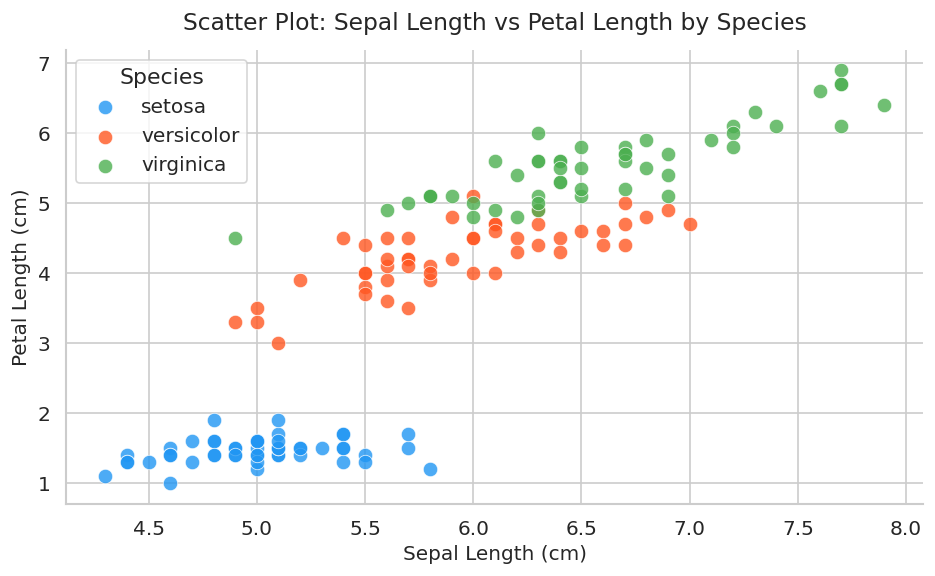

💡 Insight: Setosa is completely isolated (bottom cluster).
   Versicolor & Virginica overlap slightly in the upper region.


In [7]:
# ── Consistent Color Palette (used in all plots below) ───────────────────
PALETTE = {"setosa": "#2196F3", "versicolor": "#FF5722", "virginica": "#4CAF50"}

# ── Scatter Plot ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for species, group in df.groupby("species"):
    ax.scatter(
        group["sepal_length"],      # X-axis: sepal length
        group["petal_length"],      # Y-axis: petal length
        label=species,
        color=PALETTE[species],
        alpha=0.80,
        edgecolors="white",
        linewidths=0.5,
        s=75
    )

ax.set_xlabel("Sepal Length (cm)", fontsize=12)
ax.set_ylabel("Petal Length (cm)", fontsize=12)
ax.set_title("Scatter Plot: Sepal Length vs Petal Length by Species",
             fontsize=14, pad=12)
ax.legend(title="Species", framealpha=0.8)

plt.tight_layout()
plt.savefig("scatter_plot.png", dpi=150, bbox_inches="tight")
plt.show()

print("💡 Insight: Setosa is completely isolated (bottom cluster).")
print("   Versicolor & Virginica overlap slightly in the upper region.")


---
## 📈 Section 7 — Visualization 2: Pair Plot (Scatter Matrix)

**Purpose:** Show *every pairwise combination* of features in one grid.  
- **Diagonal:** Kernel Density Estimate (smooth distribution) per species  
- **Off-diagonal:** Scatter plot for each feature pair


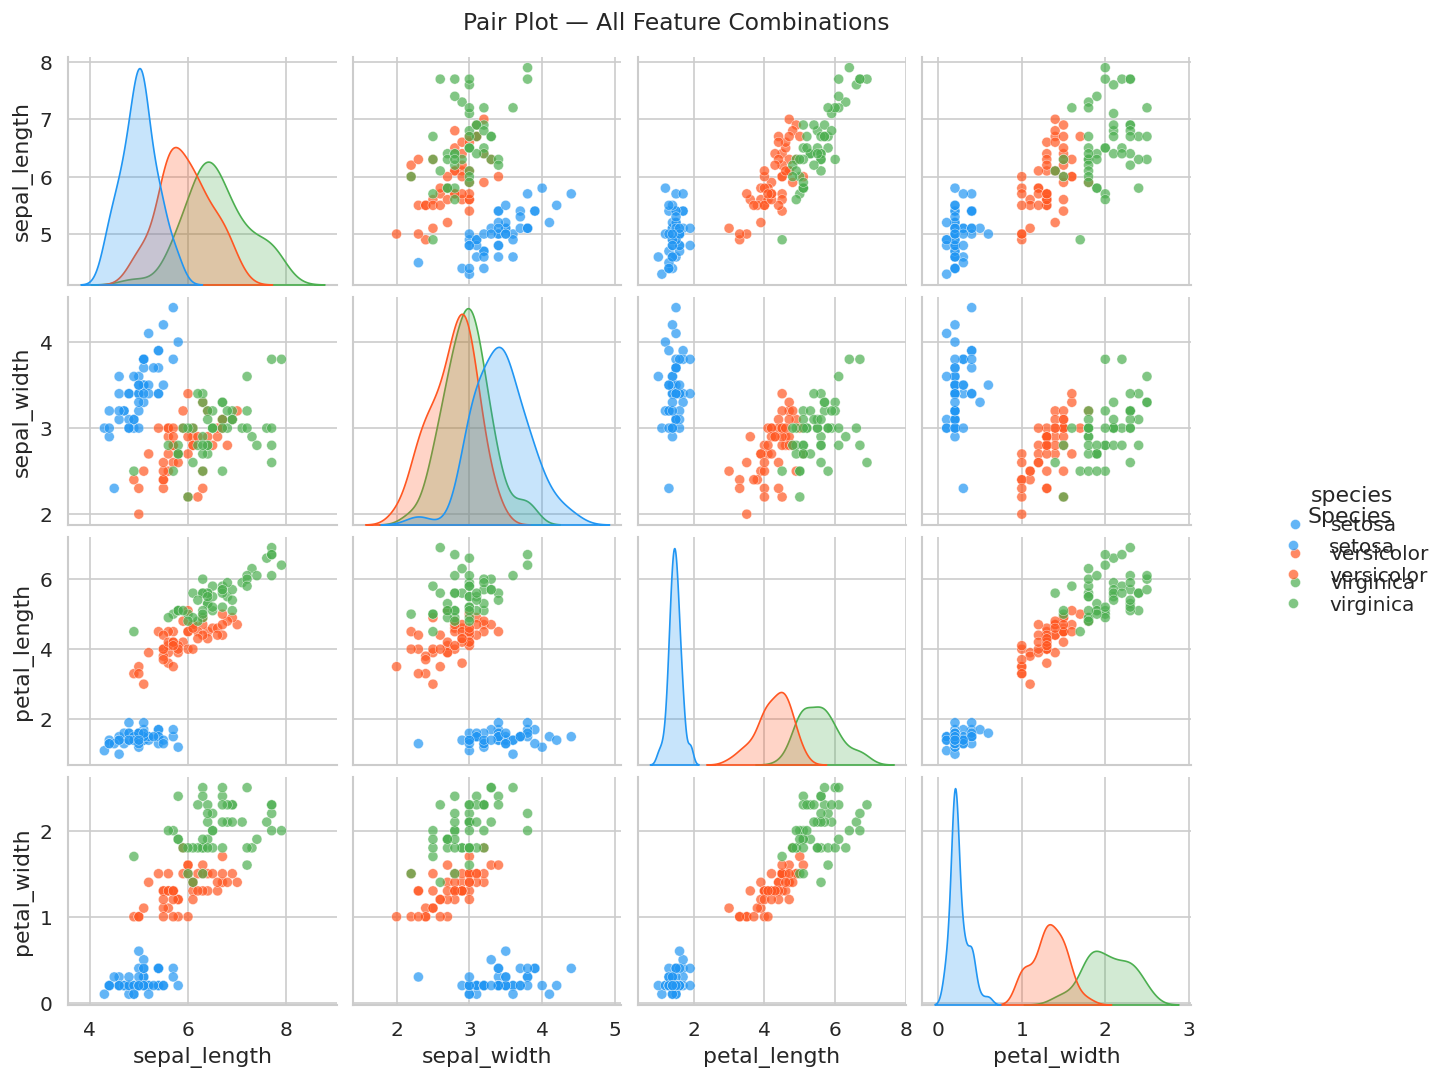

💡 Insight: petal_length vs petal_width shows the cleanest linear separation.
   KDE diagonals confirm setosa is far from the other two species.


In [8]:
# ── Pair Plot — all 4 features × all 4 features ───────────────────────────
pair_grid = sns.pairplot(
    df,
    hue="species",
    palette=PALETTE,
    diag_kind="kde",                                    # KDE on diagonal
    plot_kws={"alpha": 0.70, "edgecolor": "white", "linewidth": 0.3},
    height=2.2
)

pair_grid.fig.suptitle("Pair Plot — All Feature Combinations", y=1.02, fontsize=14)
pair_grid.add_legend(title="Species", bbox_to_anchor=(1.05, 0.5))

plt.savefig("pairplot.png", dpi=120, bbox_inches="tight")
plt.show()

print("💡 Insight: petal_length vs petal_width shows the cleanest linear separation.")
print("   KDE diagonals confirm setosa is far from the other two species.")


---
## 📊 Section 8 — Visualization 3: Histograms

**Purpose:** Show the *frequency distribution* of each individual feature.

**How to read:** X = feature value, Y = how many samples fall in that bin.  
When overlaid per species, we can see whether distributions overlap or separate.


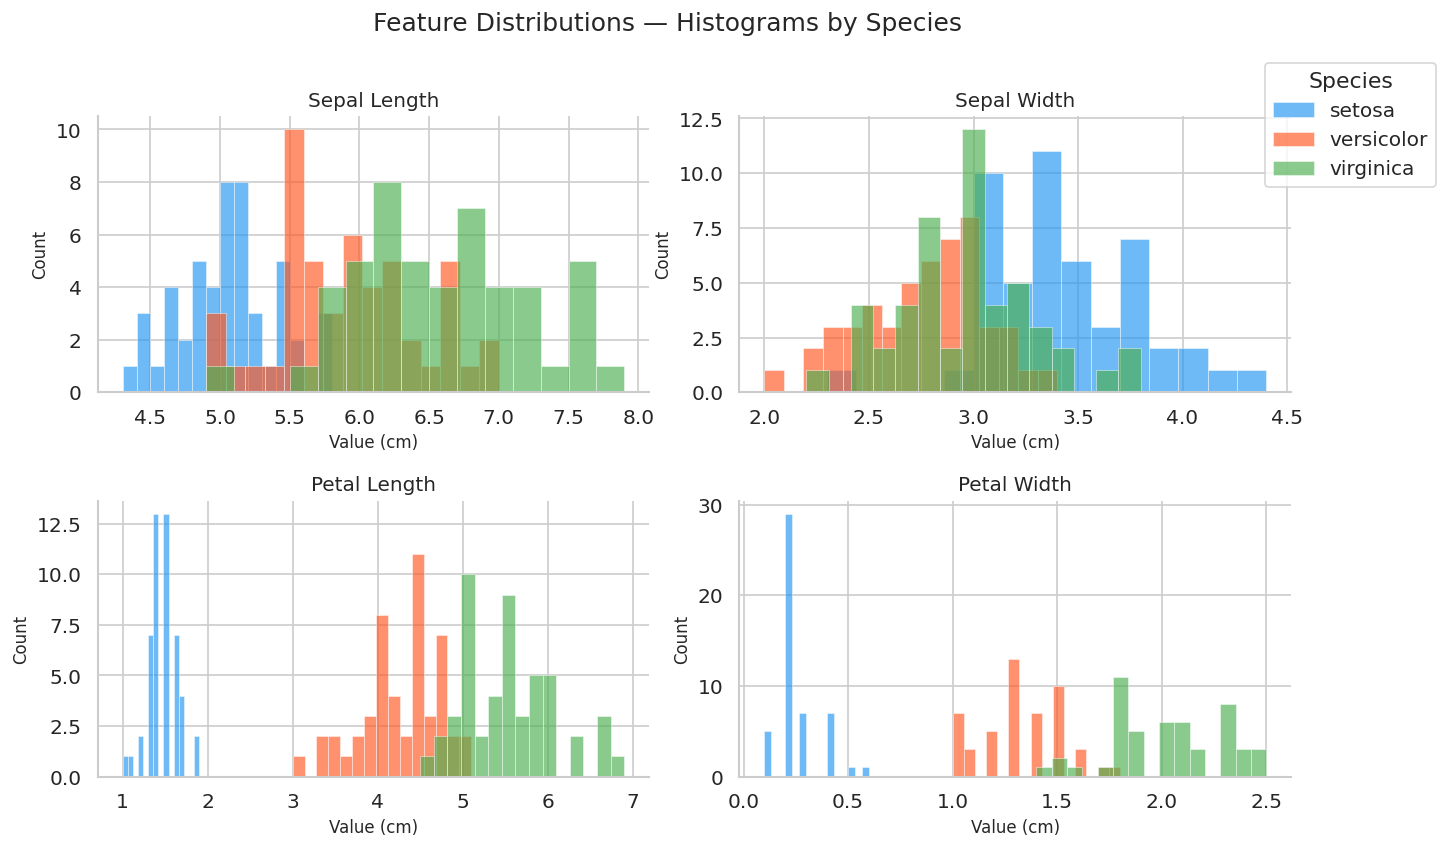

💡 Insight: petal_length and petal_width are BIMODAL — setosa sits far left.
   Sepal features have more unimodal, overlapping distributions.


In [9]:
# ── 2×2 Histogram Grid (one per feature) ─────────────────────────────────
features  = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Feature Distributions — Histograms by Species", fontsize=15, y=1.01)

for ax, feat in zip(axes.flat, features):
    # Overlay one histogram per species with transparency
    for species, group in df.groupby("species"):
        ax.hist(
            group[feat],
            bins=15,
            alpha=0.65,
            label=species,
            color=PALETTE[species],
            edgecolor="white",
            linewidth=0.4
        )
    ax.set_title(feat.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel("Value (cm)", fontsize=10)
    ax.set_ylabel("Count",      fontsize=10)

# ── One shared legend for all subplots ───────────────────────────────────
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Species", loc="upper right",
           bbox_to_anchor=(1.09, 0.96), framealpha=0.8)

plt.tight_layout()
plt.savefig("histograms.png", dpi=150, bbox_inches="tight")
plt.show()

print("💡 Insight: petal_length and petal_width are BIMODAL — setosa sits far left.")
print("   Sepal features have more unimodal, overlapping distributions.")


---
## 📦 Section 9 — Visualization 4: Box Plots

**Purpose:** Visualize the *spread, median, and outliers* for each feature, grouped by species.

| Box Element | Meaning |
|---|---|
| Box (rectangle) | Interquartile Range — middle 50% of data (Q1 to Q3) |
| Center line | Median (Q2 — 50th percentile) |
| Whiskers | Extend to 1.5 × IQR beyond Q1 and Q3 |
| Individual dots | **Outliers** — values beyond the whiskers |


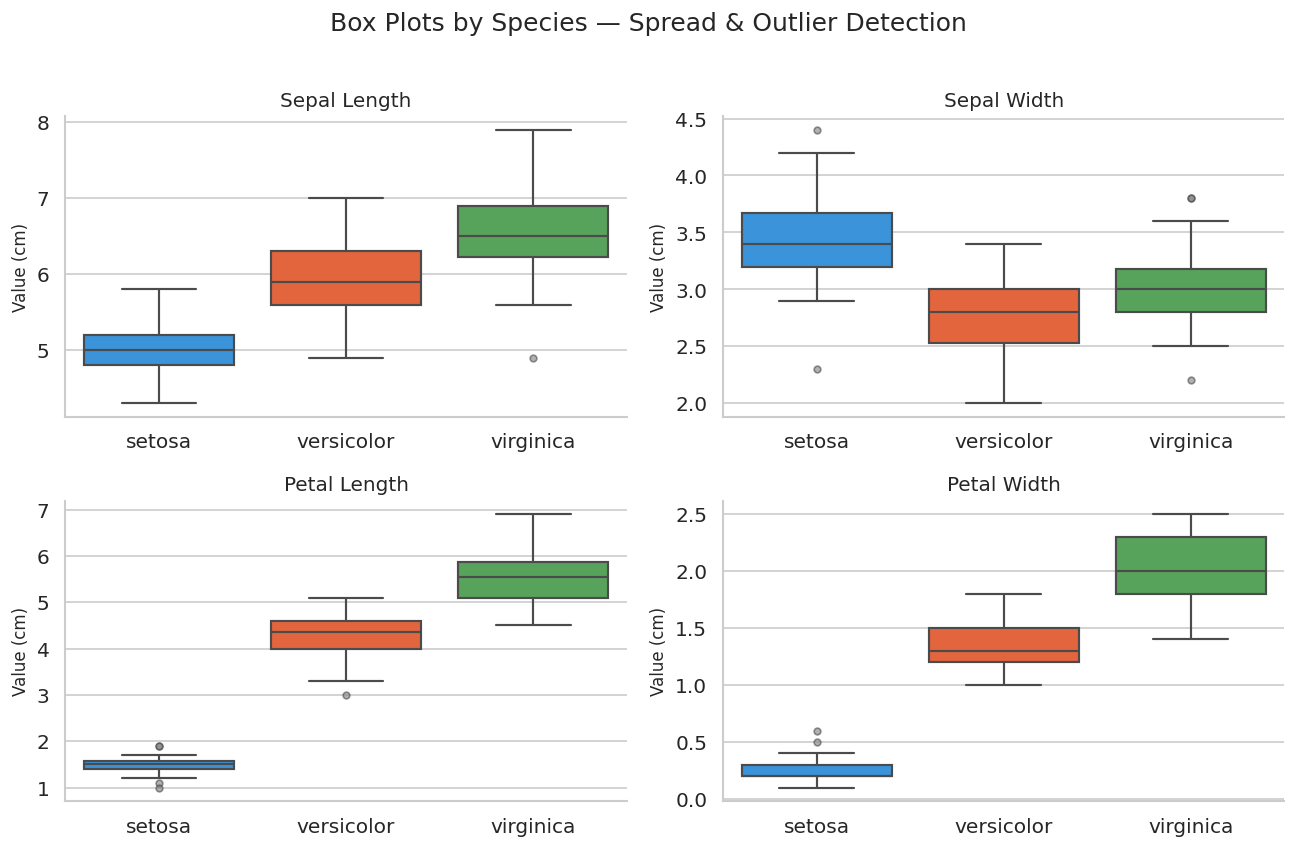

💡 Insight: sepal_width in setosa shows high-end outliers.
   petal_length and petal_width cleanly rank: setosa < versicolor < virginica.


In [10]:
# ── 2×2 Box Plot Grid ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Box Plots by Species — Spread & Outlier Detection", fontsize=15, y=1.01)

for ax, feat in zip(axes.flat, features):
    sns.boxplot(
        data=df,
        x="species",
        y=feat,
        ax=ax,
        hue="species",       # hue required in seaborn v0.13+ to use palette without warning
        palette=PALETTE,
        legend=False,
        linewidth=1.3,
        flierprops=dict(     # Customize outlier marker style
            marker="o",
            markerfacecolor="gray",
            markersize=4,
            alpha=0.6
        )
    )
    ax.set_title(feat.replace("_", " ").title(), fontsize=12)
    ax.set_xlabel("")
    ax.set_ylabel("Value (cm)", fontsize=10)

plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

print("💡 Insight: sepal_width in setosa shows high-end outliers.")
print("   petal_length and petal_width cleanly rank: setosa < versicolor < virginica.")


---
## 🔥 Section 10 — Visualization 5: Correlation Heatmap

**Purpose:** Quantify *linear relationships* between all numeric features.  

| Correlation Value | Meaning |
|---|---|
| +1.0 | Perfect positive linear relationship |
| 0.0 | No linear relationship |
| -1.0 | Perfect negative linear relationship |


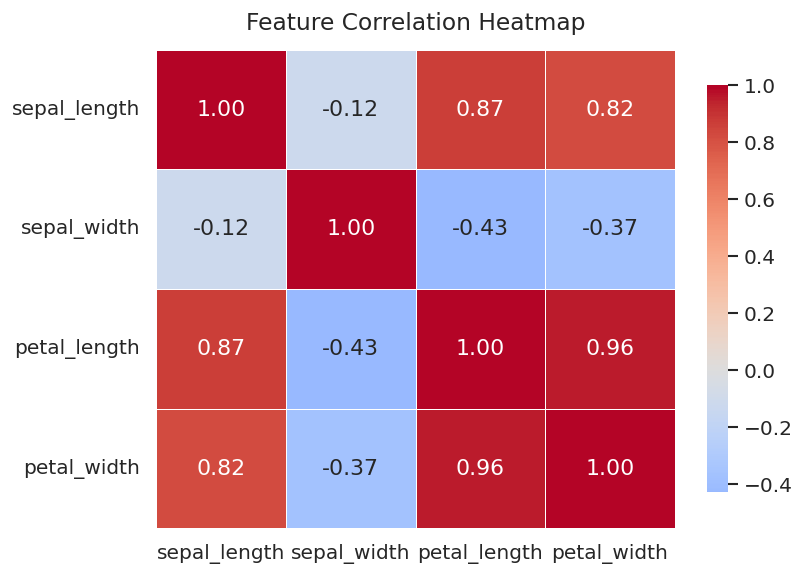

💡 Insight: petal_length ↔ petal_width → r = 0.96 (very strong positive correlation).
   sepal_width is weakly/negatively correlated with all other features.


In [11]:
# ── Compute Pearson Correlation Matrix ───────────────────────────────────
corr_matrix = df[features].corr().round(2)

# ── Plot Heatmap ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

sns.heatmap(
    corr_matrix,
    annot=True,          # Display correlation values inside cells
    fmt=".2f",           # 2 decimal places
    cmap="coolwarm",     # Blue = negative, Red = positive
    center=0,            # Center color scale at 0
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    cbar_kws={"shrink": 0.85}
)

ax.set_title("Feature Correlation Heatmap", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("💡 Insight: petal_length ↔ petal_width → r = 0.96 (very strong positive correlation).")
print("   sepal_width is weakly/negatively correlated with all other features.")


---
## ✅ Section 11 — Summary of Results & Final Insights

### 📋 Steps Completed

| # | Step | Tool Used |
|---|---|---|
| 1 | Loaded dataset | `sklearn.load_iris()` + `pandas` |
| 2 | Inspected shape, types, nulls, class balance | `.info()`, `.isnull()`, `.value_counts()` |
| 3 | Computed descriptive statistics | `.describe()`, `.groupby().mean()` |
| 4 | Scatter Plot — feature relationships | `matplotlib` |
| 5 | Pair Plot — all feature combinations | `seaborn.pairplot()` |
| 6 | Histograms — value distributions | `matplotlib.hist()` |
| 7 | Box Plots — outlier detection | `seaborn.boxplot()` |
| 8 | Correlation Heatmap — feature correlation | `seaborn.heatmap()` |

---

### 🔑 Key Findings

**1. Clean dataset — no preprocessing needed**
- 150 samples, 0 null values, perfectly balanced (50 per species)

**2. Setosa is linearly separable**
- Across every single plot, *setosa* forms a completely isolated cluster
- It has significantly smaller petal length (mean = 1.46 cm vs 4.26 for versicolor)

**3. Petal features are the most powerful class separators**
- `petal_length` std = 1.77 (highest variation of all features)
- Petal measurements alone can distinguish all 3 species with minimal overlap

**4. Petal length and petal width are nearly redundant**
- Pearson correlation r = **0.96** — nearly perfectly correlated
- Using both adds little extra information for modelling

**5. Versicolor and Virginica share sepal dimensions**
- A model using only sepal features would struggle to distinguish them
- Adding petal measurements resolves the ambiguity

**6. Outliers detected in sepal_width (setosa)**
- A few high-value points visible in the box plot
- These appear to be valid measurements, not data errors

---

### 🚀 What's Next?

> With these EDA insights, the natural next step is **supervised classification**.
> Using `petal_length` and `petal_width` as primary features, a simple model
> (KNN, Logistic Regression, or Decision Tree) can achieve very high accuracy on this dataset.
